# S11: Analisis de Test A/B de una tienda online

### Descripción del proyecto

### Contexto

Eres analista en una gran tienda online. Junto con el departamento de marketing has recopilado una lista de hipótesis que pueden ayudar a aumentar los ingresos.

Tienes que priorizar estas hipótesis, lanzar un test A/B y analizar los resultados.

### Descripción de los datos

### Datos utilizados en la primera parte del proyecto

`/datasets/hypotheses_us.csv`

* `Hypotheses`: breves descripciones de las hipótesis.
* `Reach`: alcance del usuario, en una escala del uno a diez.
* `Impact`: impacto en los usuarios, en una escala del uno al diez.
* `Confidence`: confianza en la hipótesis, en una escala del uno al diez.
* `Effort`: los recursos necesarios para probar una hipótesis, en una escala del uno al diez. Cuanto mayor sea el valor Effort, más recursos requiere la prueba.

## Parte 1. Priorizar hipótesis

El archivo `hypotheses_us.csv` contiene nueve hipótesis sobre cómo aumentar los ingresos de una tienda online con `Reach`, `Impact`, `Confidence` y `Effort` especificados para cada hipotesis.

El ejercicio consiste en:

* Aplicar el framework `ICE` para priorizar hipótesis. Ordenarlas en orden descendente de prioridad.
* Aplicar el framework `RICE` para priorizar hipótesis. Ordenarlas en orden descendente de prioridad.
* Mostrar cómo cambia la priorización de hipótesis cuando utilizas `RICE` en lugar de `ICE`. Proporcionar una explicación de los cambios.

## 1.1 Cargar y revisar datos

In [1]:
# Importar librerias
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

In [2]:
# Leer dataset de las hipotesis
hypotheses_data = pd.read_csv('/datasets/hypotheses_us.csv', sep=';')

In [3]:
# Revisar informacion del dataset
hypotheses_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


In [4]:
# Imprimir dataset
hypotheses_data

,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1
5,Add a customer review page. This will increase...,3,2,2,3
6,Show banners with current offers and sales on ...,5,3,8,3
7,Add a subscription form to all the main pages....,10,7,8,5
8,Launch a promotion that gives users discounts ...,1,9,9,5


### === Observaciones del dataset hypotheses ===

El dataset hypotheses contiene 9 hipotesis que proponen una forma de aumentar los ingresos de la tienda online, cada una con un valor asociado para calcular su ICE y su RICE. Las columnas son Hypothesis, Reach, Impact, Confidence y Effort (Hipotesis, Alcance, Impacto, Confianza y Esfuerzo).

## 1.2 Aplicar el framework ICE

Vamos a aplicar el framework ICE para lo cual tenemos que calcular el ICE para cada hipotesis. Lo que haremos sera crear una nueva columna que calculara el ICE en base a los valores de las otras columnas. Luego ordenaremos los resultados por ICE en orden descendente de prioridad.

In [5]:
# Crear la columna ICE y calcular su valor para cada hipotesis
hypotheses_data['ICE'] = (hypotheses_data['Impact'] * hypotheses_data['Confidence']) / hypotheses_data['Effort']

In [6]:
# Mostrar resultados
hypotheses_data.sort_values('ICE', ascending=False)

,Hypothesis,Reach,Impact,Confidence,Effort,ICE
8,Launch a promotion that gives users discounts ...,1,9,9,5,16.200000
0,Add two new channels for attracting traffic. T...,3,10,8,6,13.333333
7,Add a subscription form to all the main pages....,10,7,8,5,11.200000
6,Show banners with current offers and sales on ...,5,3,8,3,8.000000
2,Add product recommendation blocks to the store...,8,3,7,3,7.000000
1,Launch your own delivery service. This will sh...,2,5,4,10,2.000000
5,Add a customer review page. This will increase...,3,2,2,3,1.333333
3,Change the category structure. This will incre...,8,3,3,8,1.125000
4,Change the background color on the main page. ...,3,1,1,1,1.000000


In [7]:
# Mostrar la hipotesis con el ICE mas alto
hypotheses_data.iloc[8, 0]

'Launch a promotion that gives users discounts on their birthdays'

## 1.3 Aplicar el framework RICE

De forma similar al paso anterior, vamos a crear una nueva columna para el RICE y lo calculamos a partir de las otras columnas existentes. Ordenamos los resultados en orden descendente de prioridad.

In [8]:
# Crear la columna RICE y calcular su valor para cada hipotesis
hypotheses_data['RICE'] = (hypotheses_data['Reach'] * hypotheses_data['Impact'] * hypotheses_data['Confidence']) / hypotheses_data['Effort']

In [9]:
# Mostrar resultados
hypotheses_data.sort_values('RICE', ascending=False)

,Hypothesis,Reach,Impact,Confidence,Effort,ICE,RICE
7,Add a subscription form to all the main pages....,10,7,8,5,11.200000,112.0
2,Add product recommendation blocks to the store...,8,3,7,3,7.000000,56.0
0,Add two new channels for attracting traffic. T...,3,10,8,6,13.333333,40.0
6,Show banners with current offers and sales on ...,5,3,8,3,8.000000,40.0
8,Launch a promotion that gives users discounts ...,1,9,9,5,16.200000,16.2
3,Change the category structure. This will incre...,8,3,3,8,1.125000,9.0
1,Launch your own delivery service. This will sh...,2,5,4,10,2.000000,4.0
5,Add a customer review page. This will increase...,3,2,2,3,1.333333,4.0
4,Change the background color on the main page. ...,3,1,1,1,1.000000,3.0


In [10]:
# Mostrar la hipotesis con el RICE mas alto
hypotheses_data.iloc[7, 0]

'Add a subscription form to all the main pages. This will help you compile a mailing list'

### === Observaciones de ICE vs RICE ===

La hipotesis con el ICE mas alto fue la hipotesis 8 que dice `Launch a promotion that gives users discounts on their birthdays` (Lanzar una promocion que de a los usuarios descuentos en su cumpleaños). Esta hipotesis tiene un puntaje de 16.2.

Por otro lado, la hipotesis con el RICE mas alto fue la hipotesis 7 que dice `Add a subscription form to all the main pages. This will help you compile a mailing list` (Añade un formulario de suscripción a todas las páginas principales. Esto te ayudará a crear una lista de correo). Esta hipotesis obtuvo un puntaje de 112, el doble de la hipotesis siguiente con 56.

Mientras que el alcance de la hipotesis 8 es de 1, dado que afecta solo a cierta cantidad de clientes durante una fecha especifica, el alcance de la hipotesis 7 es de 10, puesto que afectaria a la totalidad de usuarios que acceden a la tienda online. La metrica de Reach (alcance) es la que esta cambiando los resultados tan drasticamente, puesto que ambas hipotesis tienen 5 en esfuerzo. Aunque el impacto y la confianza son un poco mayores en la hipotesis 8 que en la hipotesis 7, la hipotesis 7 parece ser la mejor opcion.

## Parte 2. Análisis del test A/B

Vamos a revisar los resultados de una prueba A/B. Los resultados estan descritos en los archivos `orders_us.csv` y `visits_us.csv`.

### Datos utilizados en la segunda parte del proyecto

`/datasets/orders_us.csv`

* `transactionId`: identificador de pedido.
* `visitorId`: identificador del usuario que realizó el pedido.
* `date`: fecha del pedido.
* `revenue`: ingresos del pedido.
* `group`: el grupo del test A/B al que pertenece el usuario.

`/datasets/visits_us.csv`

* `date`: la fecha.
* `group`: grupo de la prueba A/B.
* `visits`: el número de visitas en la fecha especificada en el grupo de pruebas A/B especificado.


### 2.0.1 Cargar y revisar datos

In [11]:
# Leer dataset orders
orders_data = pd.read_csv('/datasets/orders_us.csv')

In [12]:
# Leer dataset visits
visits_data = pd.read_csv('/datasets/visits_us.csv')

In [13]:
# Revisar informacion y tipos de datos
orders_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB


In [14]:
# Imprimir muestra de orders
orders_data.head()

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B


In [15]:
# Revisar informacion y tipos de datos
visits_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    62 non-null     object
 1   group   62 non-null     object
 2   visits  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


In [16]:
# Imprimir muestra de visits
visits_data.head()

,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


In [17]:
# Revisar duplicados en orders
orders_data.duplicated().sum()

0

In [18]:
# Revisar duplicados en visits
visits_data.duplicated().sum()

0

### === Observaciones ===

Los datos del dataframe `orders_data` no contiene valores ausente ni duplicados, sin embargo para mayor comodidad podemos estandarizar los nombres de columnas y podemos corregir el tipo de dato de la fecha. El dataframe `visits_data` esta limpio y casi listo, solo vamos a corregir el tipo de dato de la columna de fecha `date`.

### 2.0.2 Estandarizar y corregir datos

* Vamos a estandarizar los nombres de columnas en el dataframe orders_data y agregar guion bajo donde sea necesario.
* Vamos corregir el tipo de dato de fecha a tipo datetime.

In [19]:
# Estandarizar nombres de columnas a minusculas y renombrar columnas
orders_data.columns = orders_data.columns.str.strip().str.lower()
orders_data.columns = ['transaction_id', 'visitor_id', 'date', 'revenue', 'group']

In [20]:
# Orders: Cambiar tipo de dato de la columna date a datetime
orders_data['date'] = pd.to_datetime(orders_data['date'])

In [21]:
# Visits: Cambiar tipo de dato de la columna date a datetime
visits_data['date'] = pd.to_datetime(visits_data['date'])

### 2.1 Representar gráficamente el ingreso acumulado por grupo

Una vez corregidos los datos podemos comenzar su analisis. Comenzaremos analizando el ingreso acumulado por grupo, es decir, a lo largo de los dias como fue aumentando el ingreso acumulado para cada grupo. A partir del dataframe `orders_data` agrupamos por fecha y grupo y calculamos el `revenue`. Luego calculamos el revenue acumulativo.

In [22]:
# Agrupar ingresos por fecha y grupo
revenue_by_date_group = orders_data.groupby(['date', 'group'])['revenue'].sum().reset_index()

In [23]:
# Calcular ingreso acumulado para cada grupo
revenue_by_date_group['revenue_cumulative'] = revenue_by_date_group.groupby('group')['revenue'].cumsum()

In [24]:
# Mostrar resultados
revenue_by_date_group

,date,group,revenue,revenue_cumulative
0,2019-08-01,A,2356.8,2356.8
1,2019-08-01,B,1620.0,1620.0
2,2019-08-02,A,1503.5,3860.3
3,2019-08-02,B,2623.8,4243.8
4,2019-08-03,A,1815.2,5675.5
...,...,...,...,...
57,2019-08-29,B,3623.7,87343.0
58,2019-08-30,A,1364.3,63563.5
59,2019-08-30,B,3393.3,90736.3
60,2019-08-31,A,991.4,64554.9


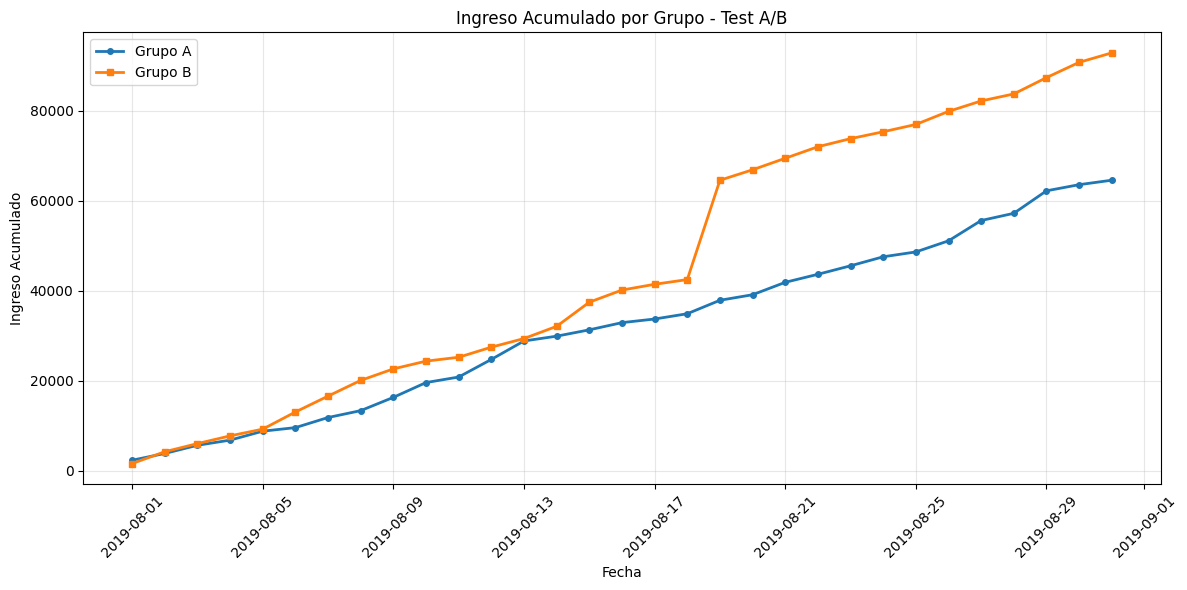

In [25]:
# Graficar líneas para cada grupo
plt.figure(figsize=(12, 6))

# Separar datos por grupo
revenue_group_a = revenue_by_date_group[revenue_by_date_group['group'] == 'A']
revenue_group_b = revenue_by_date_group[revenue_by_date_group['group'] == 'B']

plt.plot(revenue_group_a['date'], revenue_group_a['revenue_cumulative'], 
         label='Grupo A', linewidth=2, marker='o', markersize=4)
plt.plot(revenue_group_b['date'], revenue_group_b['revenue_cumulative'], 
         label='Grupo B', linewidth=2, marker='s', markersize=4)

plt.title('Ingreso Acumulado por Grupo - Test A/B')
plt.xlabel('Fecha')
plt.ylabel('Ingreso Acumulado')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### === Observaciones ===

La grafica muestra como los ingresos de ambos grupos fueron muy similares los primeros 5 dias. Posteriormente los ingresos acumulados del grupo B se incrementaron un poco mas que el grupo A y a partir del dia 13 los ingresos del grupo B fueron claramente superiores que los del grupo A. Al final, los ingresos del grupo A fueron: 64554.9, mientras que los ingresos del grupo B fueron: 92840.6. Esto es (64554.9 / 92840.6) x 100 = 69.53 %, es decir que el grupo B tuvo un poco mas de 30% mas de ingresos que el grupo A.

### 2.2 Representar gráficamente el tamaño de pedido promedio acumulado por grupo

Ahora vamos a calcular el tamaño promedio de los pedidos de cada grupo o en otras palabras, el tamaño promedio de compra pero de manera acumulativa a largo de los dias. A partir de dataframe `orders_data` agrupamos por fecha y grupo y calculamos el revenue promedio. Luego calculamos el revenue promedio acumulado

In [26]:
# Agrupar por fecha y grupo, calculando promedio diario
avg_order_size = orders_data.groupby(['date', 'group'])['revenue'].mean().reset_index()
avg_order_size.rename(columns={'revenue': 'avg_order_size'}, inplace=True)

In [27]:
# Calcular promedio acumulado para cada grupo
avg_order_size['avg_order_size_cumulative'] = (
    avg_order_size.groupby('group')['avg_order_size']
    .expanding().mean().reset_index(level=0, drop=True)
)

In [28]:
# Mostrar resultados
avg_order_size

,date,group,avg_order_size,avg_order_size_cumulative
0,2019-08-01,A,98.200000,98.200000
1,2019-08-01,B,77.142857,77.142857
2,2019-08-02,A,75.175000,86.687500
3,2019-08-02,B,109.325000,93.233929
4,2019-08-03,A,75.633333,83.002778
...,...,...,...,...
57,2019-08-29,B,181.185000,145.668492
58,2019-08-30,A,124.027273,117.601598
59,2019-08-30,B,141.387500,145.525792
60,2019-08-31,A,82.616667,116.473052


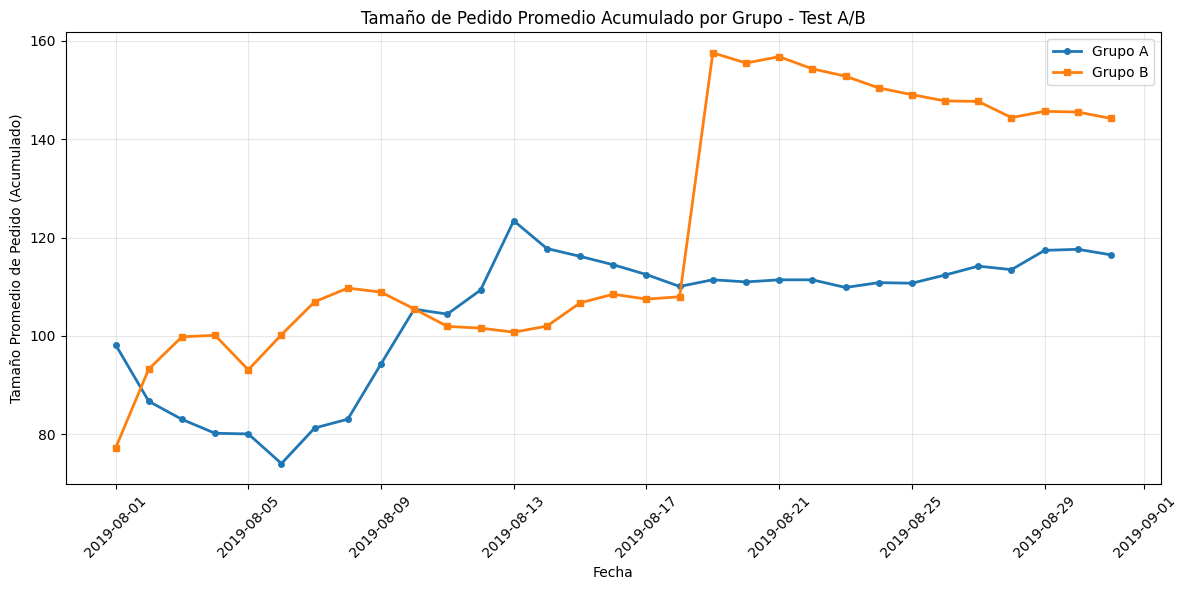

In [29]:
# Graficar líneas para cada grupo
plt.figure(figsize=(12, 6))

# Separar datos por grupo
avg_order_group_a = avg_order_size[avg_order_size['group'] == 'A']
avg_order_group_b = avg_order_size[avg_order_size['group'] == 'B']

plt.plot(avg_order_group_a['date'], avg_order_group_a['avg_order_size_cumulative'], 
         label='Grupo A', linewidth=2, marker='o', markersize=4)
plt.plot(avg_order_group_b['date'], avg_order_group_b['avg_order_size_cumulative'], 
         label='Grupo B', linewidth=2, marker='s', markersize=4)

plt.title('Tamaño de Pedido Promedio Acumulado por Grupo - Test A/B')
plt.xlabel('Fecha')
plt.ylabel('Tamaño Promedio de Pedido (Acumulado)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### === Observaciones ===

La grafica muestra un comportamiento interesante respecto al tamaño de pedidos promedio acumulados a lo largo del experimento. 

* Grupo A: El grupo A comenzo arriba del grupo B, pero durante los primeros dias fue a la baja, para posteriormente comenzar a tener un repunte y superar durante algunos dias al grupo B. Despues de lo cual descendio un poco para mantener cierta estabilidad el resto de los dias del experimento.
* Grupo B: El grupo B comenzo abajo del grupo A, pero los primeros dias su comportamiento fue hacia arriba superando por 9 dias al grupo A: Luego el grupo A logro superar al grupo B durante unos dias, mientras que el grupo B se mantuvo con cierta estabilidad. El dia 19 el grupo B tuvo un brusco repunte, superando por mucho al grupo A que se mantuvo estable el resto del experimento. El grupo B mantuvo esa ventaja con cierta estabilidad el resto de los dias.
* Nuevamente los resultados del Test A/B son favorables para el grupo B.

### 2.3 Representa gráficamente la diferencia relativa en el tamaño de pedido promedio acumulado para el grupo B en comparación con el grupo A

Vamos a utilizar los resultados del paso anterior para encontrar la diferencia relativa en el tamaño promedio del grupo B con respecto al grupo A. Vamos a utilizar la funcion pivot_table() para organizar los datos como los necesitamos.

In [30]:
# Dataframe de tamaño promedio de pedidos acumulados
avg_order_size.head(10)

,date,group,avg_order_size,avg_order_size_cumulative
0,2019-08-01,A,98.200000,98.200000
1,2019-08-01,B,77.142857,77.142857
2,2019-08-02,A,75.175000,86.687500
3,2019-08-02,B,109.325000,93.233929
4,2019-08-03,A,75.633333,83.002778
5,2019-08-03,B,112.925000,99.797619
6,2019-08-04,A,71.662500,80.167708
7,2019-08-04,B,101.017647,100.102626
8,2019-08-05,A,79.524000,80.038967
9,2019-08-05,B,65.000000,93.082101


In [31]:
# Convertir a formato pivot
pivot_avg_order_size = avg_order_size.pivot(index='date', 
                                            columns='group', 
                                            values='avg_order_size_cumulative')

# Verificar resultado
pivot_avg_order_size.head(10)

group,A,B
date,,
2019-08-01,98.200000,77.142857
2019-08-02,86.687500,93.233929
2019-08-03,83.002778,99.797619
2019-08-04,80.167708,100.102626
2019-08-05,80.038967,93.082101
2019-08-06,74.012102,100.225560
2019-08-07,81.239738,106.928456
2019-08-08,83.041021,109.709622
2019-08-09,94.280213,108.888997


In [32]:
# Calcular diferencia relativa (B vs A)
pivot_avg_order_size['diferencia_relativa'] = (
    (pivot_avg_order_size['B'] - pivot_avg_order_size['A']) / pivot_avg_order_size['A'] * 100
)

In [33]:
# Imprimir muestra
pivot_avg_order_size.head(10)

group,A,B,diferencia_relativa
date,,,
2019-08-01,98.200000,77.142857,-21.443119
2019-08-02,86.687500,93.233929,7.551756
2019-08-03,83.002778,99.797619,20.234071
2019-08-04,80.167708,100.102626,24.866518
2019-08-05,80.038967,93.082101,16.295980
2019-08-06,74.012102,100.225560,35.417800
2019-08-07,81.239738,106.928456,31.620878
2019-08-08,83.041021,109.709622,32.114972
2019-08-09,94.280213,108.888997,15.495069


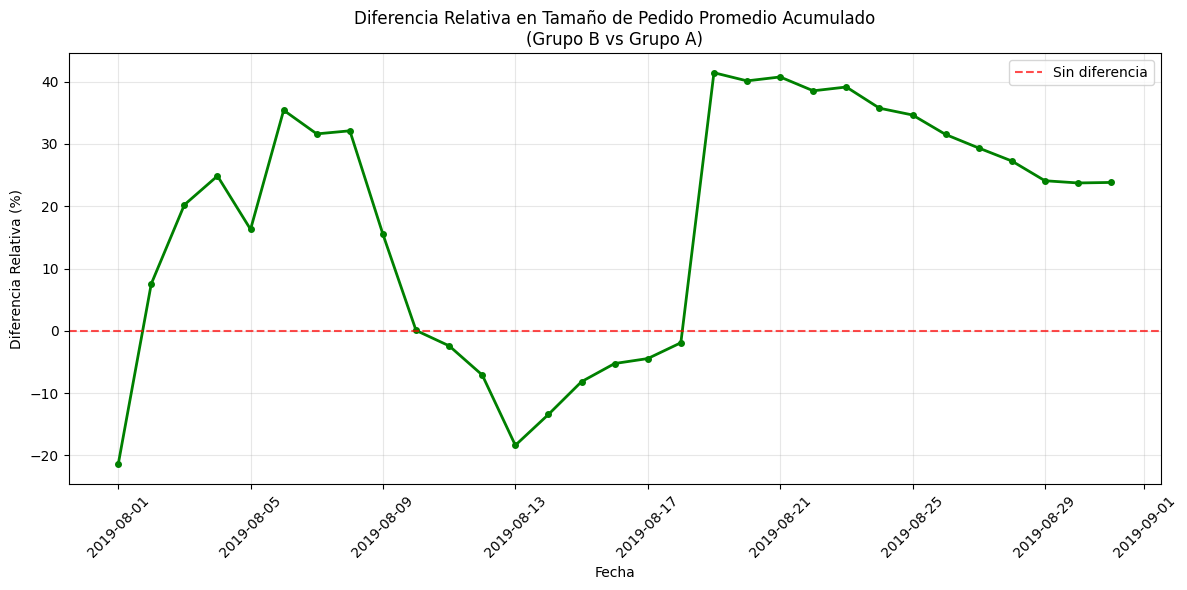

In [34]:
# Graficar la diferencia relativa
plt.figure(figsize=(12, 6))

plt.plot(pivot_avg_order_size.index, pivot_avg_order_size['diferencia_relativa'], 
         linewidth=2, marker='o', markersize=4, color='green')

# Agregar línea horizontal en 0 (sin diferencia)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Sin diferencia')

plt.title('Diferencia Relativa en Tamaño de Pedido Promedio Acumulado\n(Grupo B vs Grupo A)')
plt.xlabel('Fecha')
plt.ylabel('Diferencia Relativa (%)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### === Observaciones ===

La grafica anterior nos permite ver con exactitud cual fue la diferencia porcentual dia con dia del grupo B con respecto al grupo A en lo referente al tamaño de pedido promedio acumulado. En realidad hay dos periodos durante los cuales el grupo A fue superior al grupo B, al inicio y en un periodo intermedio. El punto inicial fue el punto mas bajo del grupo B, donde tuvo una diferencia relativa negativa de -21.4% y luego en un punto intermedio con -18.3%. Sin embargo la diferencia relativa mas notable fue cuando el grupo B supero al grupo A por un 41.4%. Al final el grupo B logro una diferencia porcentual relativa positiva del 23.8% con respecto al grupo A.

### 2.4 Calcular la tasa de conversión de cada grupo

Queremos saber la tasa de conversion de cada grupo, es decir, que porcentaje de visitantes de la tienda online se convierte en cliente para cada grupo. Para ello necesitamos los datos de los dataframes `orders_data` y `visits_data`. 

In [35]:
# Contar número de pedidos por fecha y grupo
daily_orders = orders_data.groupby(['date', 'group']).size().reset_index(name='orders_count')

In [36]:
# Mostrar resultado
daily_orders.head()

,date,group,orders_count
0,2019-08-01,A,24
1,2019-08-01,B,21
2,2019-08-02,A,20
3,2019-08-02,B,24
4,2019-08-03,A,24


In [37]:
# Visualizar datos de visitas
visits_data.head()

,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


In [38]:
# Combinar pedidos diarios y visitas
conversion_data = visits_data.merge(daily_orders, on=['date', 'group'], how='left')

In [39]:
# Imprimir resultados
conversion_data

,date,group,visits,orders_count
0,2019-08-01,A,719,24
1,2019-08-02,A,619,20
2,2019-08-03,A,507,24
3,2019-08-04,A,717,16
4,2019-08-05,A,756,25
...,...,...,...,...
57,2019-08-27,B,720,16
58,2019-08-28,B,654,28
59,2019-08-29,B,531,20
60,2019-08-30,B,490,24


In [40]:
# Calcular la tasa de conversión
conversion_data['conversion_rate_%'] = (conversion_data['orders_count'] / conversion_data['visits'])

In [41]:
# Mostrar la tasa de conversion
conversion_data

,date,group,visits,orders_count,conversion_rate_%
0,2019-08-01,A,719,24,0.033380
1,2019-08-02,A,619,20,0.032310
2,2019-08-03,A,507,24,0.047337
3,2019-08-04,A,717,16,0.022315
4,2019-08-05,A,756,25,0.033069
...,...,...,...,...,...
57,2019-08-27,B,720,16,0.022222
58,2019-08-28,B,654,28,0.042813
59,2019-08-29,B,531,20,0.037665
60,2019-08-30,B,490,24,0.048980


In [42]:
# Calcular tasa de conversion minima y maxima entre ambos grupos
print('Tasa de conversion minima:', conversion_data['conversion_rate_%'].min())
print('Tasa de conversion maxima:', conversion_data['conversion_rate_%'].max())

Tasa de conversion minima: 0.012211668928086838
Tasa de conversion maxima: 0.06233062330623306


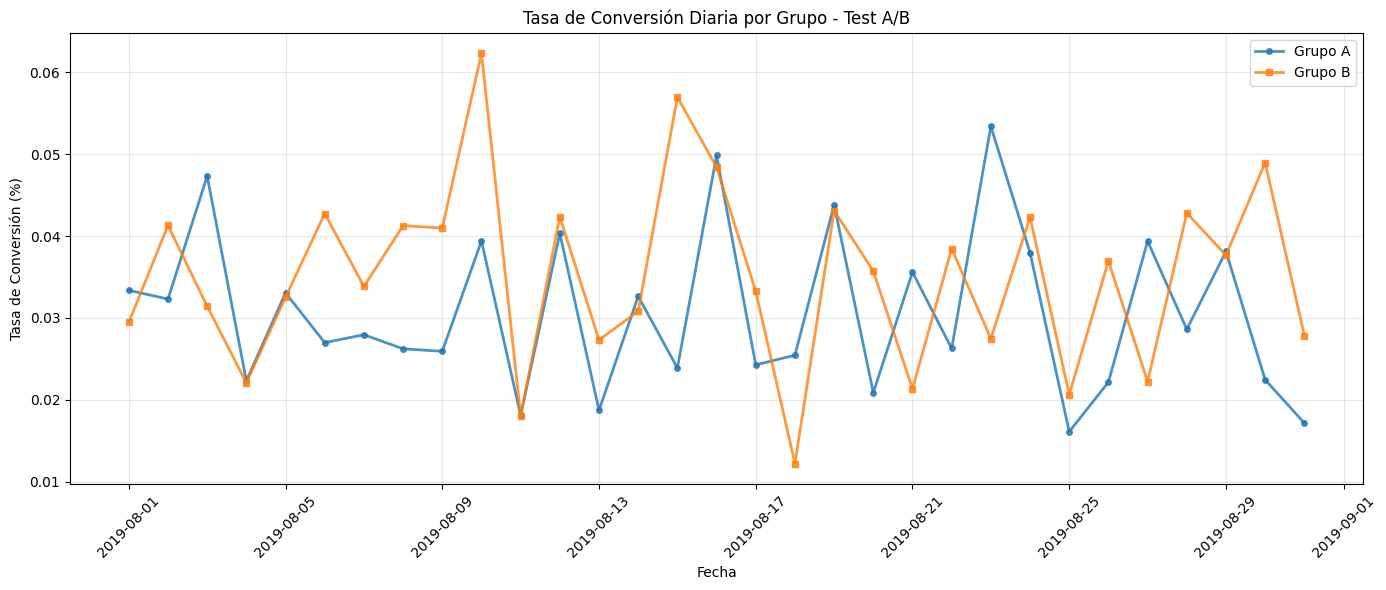

In [43]:
# Graficar tasas de conversión
plt.figure(figsize=(14, 6))

# Separar datos por grupo
conversion_group_a = conversion_data[conversion_data['group'] == 'A']
conversion_group_b = conversion_data[conversion_data['group'] == 'B']

plt.plot(conversion_group_a['date'], conversion_group_a['conversion_rate_%'], 
         label='Grupo A', linewidth=2, marker='o', markersize=4, alpha=0.8)
plt.plot(conversion_group_b['date'], conversion_group_b['conversion_rate_%'], 
         label='Grupo B', linewidth=2, marker='s', markersize=4, alpha=0.8)

plt.title('Tasa de Conversión Diaria por Grupo - Test A/B')
plt.xlabel('Fecha')
plt.ylabel('Tasa de Conversión (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
# Calcular tasa de conversion promedio de cada grupo
print('Grupo A - Tasa de conversion promedio:', conversion_data[conversion_data['group'] == 'A']['conversion_rate_%'].mean())
print('Grupo B - Tasa de conversion promedio:', conversion_data[conversion_data['group'] == 'B']['conversion_rate_%'].mean())

Grupo A - Tasa de conversion promedio: 0.030650668894803366
Grupo B - Tasa de conversion promedio: 0.03525747171315125


### === Observaciones ===

Debemos observar como la tasa de conversion entre ambos grupos se mantiene en un rango de entre poco mas de 1% hasta poco mas de 6%. El punto mas alto en la tasa de conversion lo tuvo el grupo B con un 6.23%, sin embargo tambien obtuvo el punto de conversion mas bajo con un 1.22%.

La tasa de conversion promedio del grupo B fue ligeramente superior que la del grupo A. No podriamos asumir con seguridad si esta diferencia es realmente significativa, aun con los resultados positivos de los analisis anteriores para el grupo B.

### 2.5 Trazar un gráfico de dispersión del número de pedidos por usuario

Ahora nos interesa saber la cantidad de pedidos que realizo cada usuario durante el experimento. Para esto vamos agrupar el dataframe `orders_data` por id de usuario y contrar el numero de transacciones de cada usuario. Luego graficamos los resultados.

In [45]:
# Agrupar y calcular el numero de transacciones por usuario
orders_by_user = orders_data.groupby('visitor_id')['transaction_id'].size().reset_index(name='num_pedidos')

In [46]:
# imprimir la tabla
orders_by_user.head(10)

,visitor_id,num_pedidos
0,5114589,1
1,6958315,1
2,8300375,2
3,11685486,1
4,39475350,1
5,47206413,1
6,48147722,1
7,54447517,1
8,56960363,1
9,66685450,1


In [1]:
# Visualizar pedidos por usuario con un histograma
plt.figure(figsize=(10, 6))
plt.hist(orders_by_user['num_pedidos'], bins=10, edgecolor='black', alpha=0.7)
plt.title('Histograma de numero de pedidos por usuario')
plt.xlabel('Numero de pedidos')
plt.ylabel('Frecuencia')
plt.show()

NameError: name 'plt' is not defined

In [48]:
# Ver la distribución
print("Estadísticas del número de pedidos por usuario:")
print(orders_by_user['num_pedidos'].describe())

Estadísticas del número de pedidos por usuario:
count    1031.000000
mean        1.161009
std         0.724919
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        11.000000
Name: num_pedidos, dtype: float64


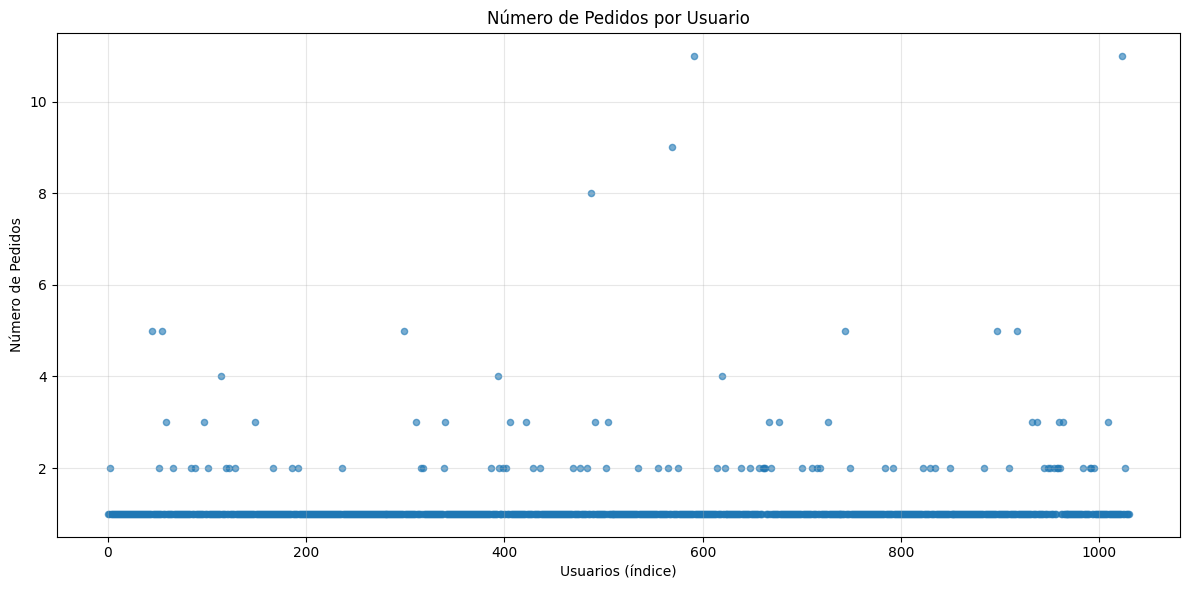

In [49]:
# Gráfico de dispersión
plt.figure(figsize=(12, 6))

# Crear índice para el eje X (cada punto es un usuario)
x_values = range(len(orders_by_user))

plt.scatter(x_values, orders_by_user['num_pedidos'], 
           alpha=0.6, s=20)

plt.title('Número de Pedidos por Usuario')
plt.xlabel('Usuarios (índice)')
plt.ylabel('Número de Pedidos')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### === Observaciones ===

A partir de histograma de pedidos por usuario ya observamos que la gran mayoria de cliente realizo unicamente un pedido, durante el experimento. Sin embargo, con la grafica de dispersion podemos ver mas claramente los numeros. Tenemos unos pocos puntos (usuarios) que realizaron mas de 4 pedidos, solo 4 que realizaron mas de 8 y solo 2 que realizaron mas de 10.

### 2.6 Calcular los percentiles 95 y 99 del número de pedidos por usuario

Ahora necesitamos identificar cuando el numero de pedidos se vuelve una anomalia, es decir, que cantidad de pedidos ya se sale del rango de la mayoria de usuarios. Para ello tendremos que calcular los percentiles 95 y 99 del numero de pedidos por usuario.

In [50]:
# Contar número de pedidos por usuario
print("Distribución del número de pedidos por usuario:")
print(orders_by_user['num_pedidos'].describe())

Distribución del número de pedidos por usuario:
count    1031.000000
mean        1.161009
std         0.724919
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        11.000000
Name: num_pedidos, dtype: float64


In [51]:
# Calcular percentiles 95 y 99 del número de pedidos por usuario
percentil_95_pedidos = np.percentile(orders_by_user['num_pedidos'], 95)
percentil_99_pedidos = np.percentile(orders_by_user['num_pedidos'], 99)

print(f"Percentil 95 de pedidos por usuario: {percentil_95_pedidos:.0f} pedidos")
print(f"Percentil 99 de pedidos por usuario: {percentil_99_pedidos:.0f} pedidos")

Percentil 95 de pedidos por usuario: 2 pedidos
Percentil 99 de pedidos por usuario: 4 pedidos


In [52]:
# Definir umbral de anomalía para usuarios en 95%
umbral_anomalia_usuarios = percentil_95_pedidos

print(f"\nPunto de anomalía definido en: {umbral_anomalia_usuarios:.0f} pedidos")
print(f"Usuarios con más de {umbral_anomalia_usuarios:.0f} pedidos se consideran anómalos")


Punto de anomalía definido en: 2 pedidos
Usuarios con más de 2 pedidos se consideran anómalos


In [53]:
# Identificar usuarios anómalos
usuarios_anomalos = orders_by_user[orders_by_user['num_pedidos'] > umbral_anomalia_usuarios]

print(f"\nNúmero total de usuarios: {len(orders_by_user)}")
print(f"Número de usuarios anómalos: {len(usuarios_anomalos)}")
print(f"Porcentaje de usuarios anómalos: {len(usuarios_anomalos)/len(orders_by_user)*100:.2f}%")

# Mostrar algunos ejemplos
print(f"\nEjemplos de usuarios anómalos:")
print(usuarios_anomalos.head(10))


Número total de usuarios: 1031
Número de usuarios anómalos: 30
Porcentaje de usuarios anómalos: 2.91%

Ejemplos de usuarios anómalos:
     visitor_id  num_pedidos
44    199603092            5
55    237748145            5
59    249864742            3
97    393266494            3
114   457167155            4
148   611059232            3
299  1230306981            5
311  1294878855            3
340  1404934699            3
393  1614305549            4


### === Observaciones ===

Usando la funcion `describe()` ya podemos observar la que al menos el 75% de usuarios solo realizaron un pedido. Sin embargo al aplicar la funcion `np.percentile()` de la libreria de numpy podemos calcular el 95% y 99% de numero de pedidos de usuarios. Al aplicar la funcion vemos que en realidad hacer mas de 2 pedidos ya se considera anomalia si tomamos en cuenta el 95% de clientes. Calculamos el porcentaje de usuarios anomalos que es 2.91%. Todos estos clientes realizaron mas de 2 pedidos.

### 2.7 Trazar un gráfico de dispersión de los precios de los pedidos

En este paso nos interesa conocer la dispersion de los precios de los pedidos, es decir, cuanto suelen gastar los clientes por pedido. Esta informacion la podemos obtener del dataframe `orders_data` y la columna `revenue`.

In [54]:
# Verificar los datos de precios
print("Estadísticas básicas de precios:")
print(orders_data['revenue'].describe())
print(f"\nNúmero total de pedidos: {len(orders_data)}")

Estadísticas básicas de precios:
count     1197.000000
mean       131.491646
std        603.004729
min          5.000000
25%         20.800000
50%         50.200000
75%        130.400000
max      19920.400000
Name: revenue, dtype: float64

Número total de pedidos: 1197


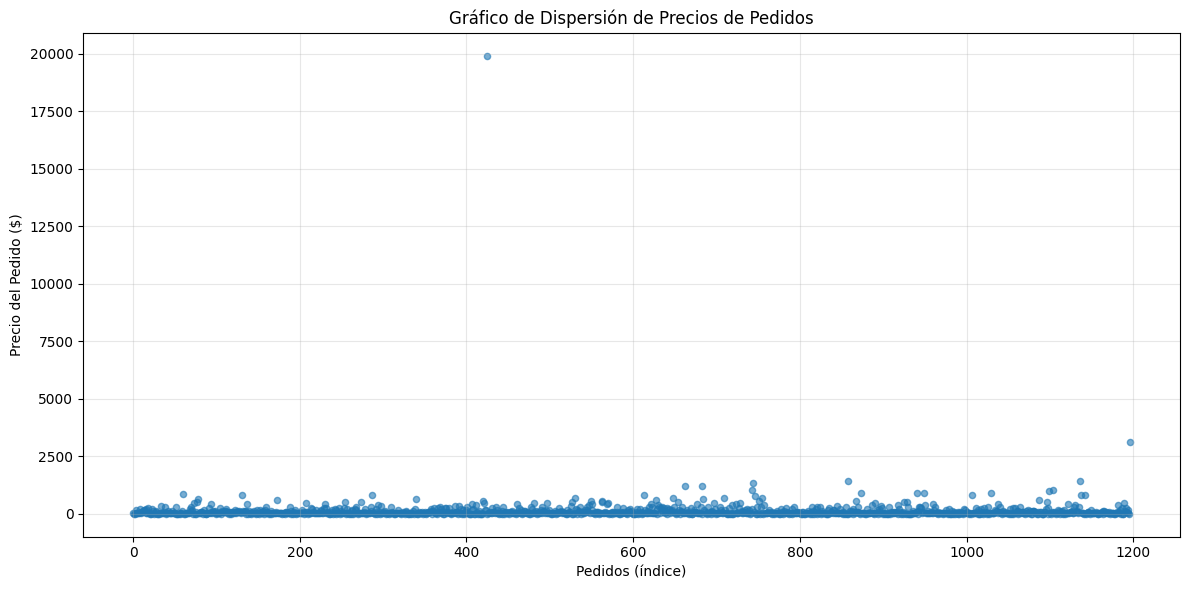

In [55]:
# Gráfico de dispersión de precios
plt.figure(figsize=(12, 6))

# Crear índice para el eje X (cada punto es un pedido)
x_values = range(len(orders_data))

plt.scatter(x_values, orders_data['revenue'], alpha=0.6, s=20)

plt.title('Gráfico de Dispersión de Precios de Pedidos')
plt.xlabel('Pedidos (índice)')
plt.ylabel('Precio del Pedido ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

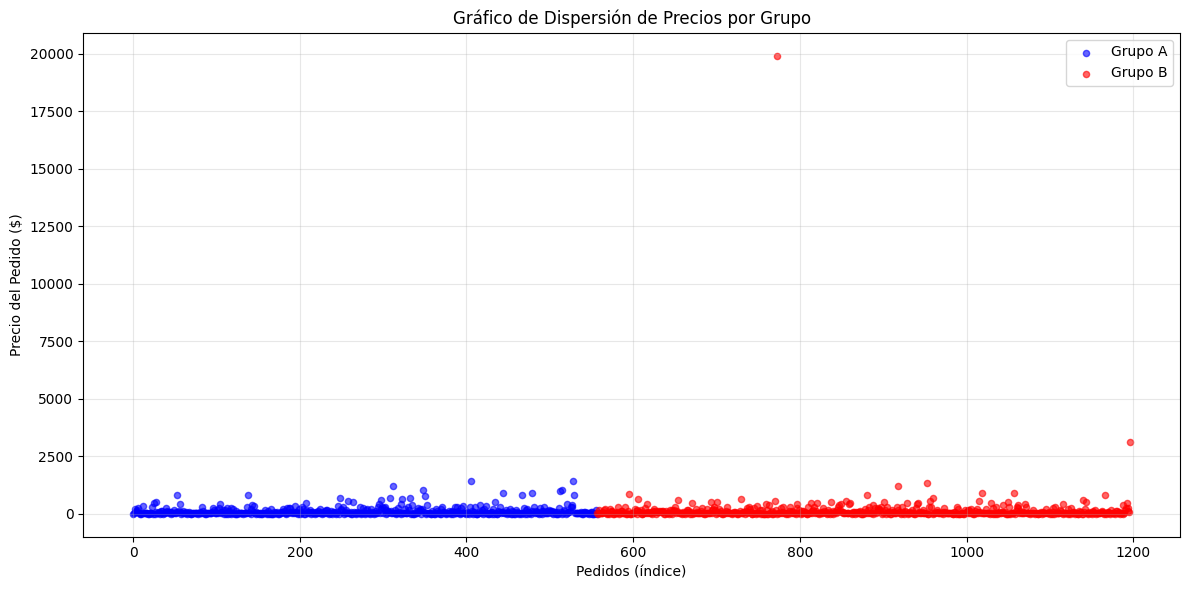

In [56]:
# Gráfico de dispersión por grupos
plt.figure(figsize=(12, 6))

# Separar por grupos
price_orders_group_a = orders_data[orders_data['group'] == 'A']
price_orders_group_b = orders_data[orders_data['group'] == 'B']

plt.scatter(range(len(price_orders_group_a)), price_orders_group_a['revenue'], 
           alpha=0.6, s=20, label='Grupo A', color='blue')
plt.scatter(range(len(price_orders_group_a), len(price_orders_group_a) + len(price_orders_group_b)), price_orders_group_b['revenue'], 
           alpha=0.6, s=20, label='Grupo B', color='red')

plt.title('Gráfico de Dispersión de Precios por Grupo')
plt.xlabel('Pedidos (índice)')
plt.ylabel('Precio del Pedido ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

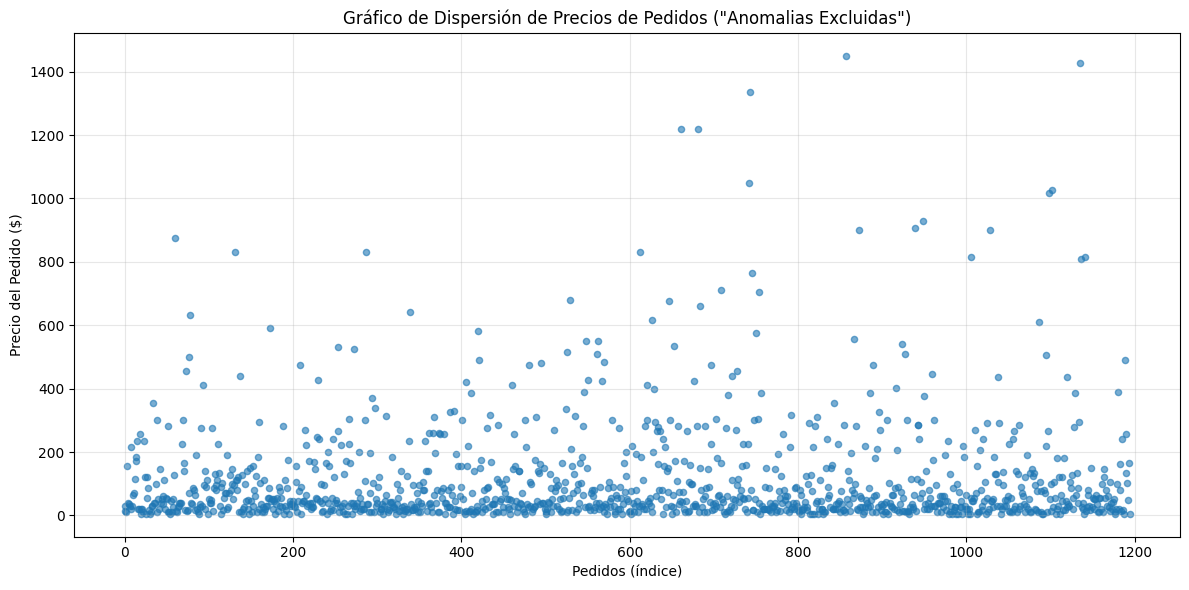

In [57]:
# Eliminar valores atipicos
precios_sin_anomalos = orders_data[orders_data['revenue'] <= 2000]

# Gráfico de dispersión de precios sin valores anomalos
plt.figure(figsize=(12, 6))

# Crear índice para el eje X (cada punto es un pedido)
x_values = range(len(precios_sin_anomalos))

plt.scatter(x_values, precios_sin_anomalos['revenue'], alpha=0.6, s=20)

plt.title('Gráfico de Dispersión de Precios de Pedidos ("Anomalias Excluidas")')
plt.xlabel('Pedidos (índice)')
plt.ylabel('Precio del Pedido ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### === Observaciones ===

El promedio de compra de un pedido es de 131.49. El grafico de dispersion muestra como la gran mayoria del valor de los pedidos se concentra entre 5 (el valor minimo) y 200. Los primero graficos de dispersion incluyen algunos valores anomalos que hacen que el eje vertical y llegue hasta el valor 20,000. Esto hace ver claramente estos valores atipicos y como la gran mayoria se concentra en valores menores a 1,000 o 500. Decidi excluir valores mayores a 2,000 para observar mas claramente la distribucion de la mayoria. En realidad un porcentaje bajo del total supera pedidos de un valor de 500 o 600, la gran mayoria se encuentra por debajo de estos numeros.

### 2.8 Calcular los percentiles 95 y 99 de los precios de los pedidos

Para identificar con exactitud el porcentaje de valores anomalos vamos calcular los pencetiles 95 y 99 de los precios de los pedidos.

In [58]:
# Calcular percentiles 95 y 99 de los precios de pedidos
percentil_95_precios = np.percentile(orders_data['revenue'], 95)
percentil_99_precios = np.percentile(orders_data['revenue'], 99)

print(f"Percentil 95 de precios de pedidos: ${percentil_95_precios:.2f}")
print(f"Percentil 99 de precios de pedidos: ${percentil_99_precios:.2f}")

Percentil 95 de precios de pedidos: $435.54
Percentil 99 de precios de pedidos: $900.90


In [59]:
# Definir umbral de anomalía para usuarios en 95%
umbral_anomalia_precios = percentil_95_precios 

print(f"\nPunto de anomalía definido en: {umbral_anomalia_precios:.0f}")
print(f"Pedidos mayores de ${umbral_anomalia_precios:.0f} se consideran anómalos")


Punto de anomalía definido en: 436
Pedidos mayores de $436 se consideran anómalos


In [60]:
# Identificar usuarios anómalos
valores_anomalos = orders_data[orders_data['revenue'] > umbral_anomalia_precios]

print(f"\nNúmero total de pedidos: {len(orders_data)}")
print(f"Número de valores anómalos: {len(valores_anomalos)}")
print(f"Porcentaje de valores anómalos: {len(valores_anomalos)/len(orders_data)*100:.2f}%")

# Mostrar algunos ejemplos
print(f"\nEjemplos de clientes anómalos:")
print(valores_anomalos.head(20))


Número total de pedidos: 1197
Número de valores anómalos: 60
Porcentaje de valores anómalos: 5.01%

Ejemplos de clientes anómalos:
     transaction_id  visitor_id       date  revenue group
60       1421016313  4256040402 2019-08-16    875.5     B
73       1295850747  2947100995 2019-08-01    455.8     A
77       2619374735   787824685 2019-08-16    500.7     A
78        773663763  3288820196 2019-08-16    630.8     B
131      3163614039  2254586615 2019-08-22    830.3     A
137      1798931686  1211585711 2019-08-01    440.3     A
173      1192036073  2953427180 2019-08-02    590.1     B
208       573486797  3118156181 2019-08-02    475.5     B
254      1545495643  2686716486 2019-08-23    530.3     B
273      1769257333  2278620397 2019-08-23    525.6     B
287       587872075  2254456485 2019-08-24    830.3     A
339      2216192667   834731816 2019-08-25    640.7     B
420      2788225284  1606766439 2019-08-06    580.7     B
421      3765974140  1357170471 2019-08-19    490.4     

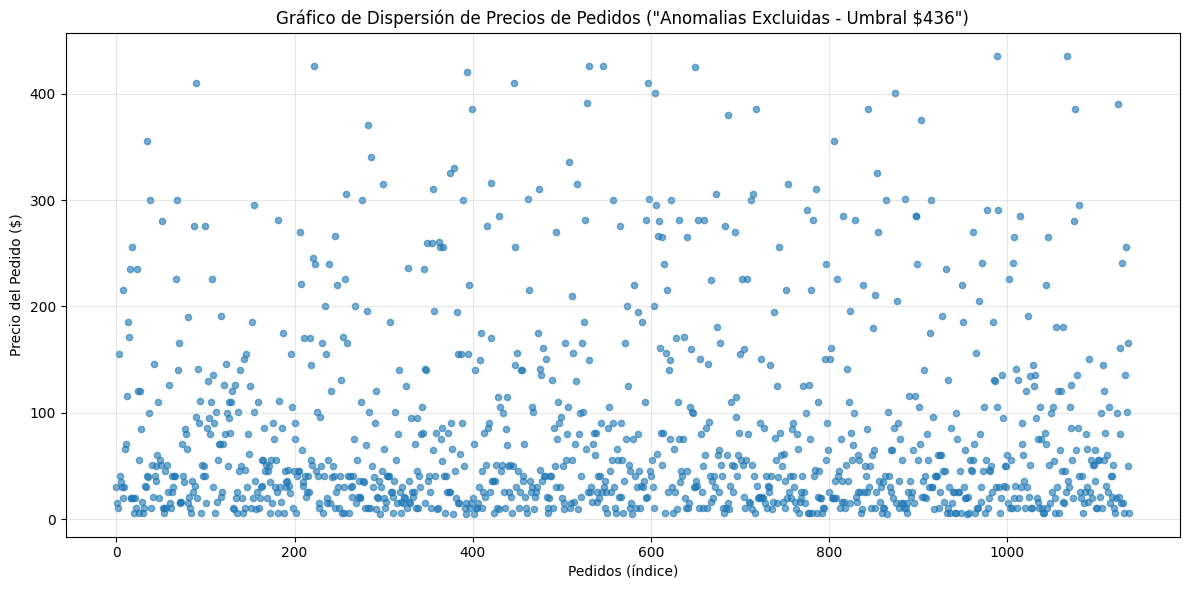

In [61]:
# Eliminar valores atipicos
precios_sin_anomalos = orders_data[orders_data['revenue'] <= 436]

# Gráfico de dispersión de precios sin valores anomalos
plt.figure(figsize=(12, 6))

# Crear índice para el eje X (cada punto es un pedido)
x_values = range(len(precios_sin_anomalos))

plt.scatter(x_values, precios_sin_anomalos['revenue'], alpha=0.6, s=20)

plt.title('Gráfico de Dispersión de Precios de Pedidos ("Anomalias Excluidas - Umbral $436")')
plt.xlabel('Pedidos (índice)')
plt.ylabel('Precio del Pedido ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### === Observaciones ===

De un total de 1197 pedidos, encontramos que 60 (praticamente un 5%) son pedidos con un valor mayor a 436. Es decir, que el 95% de los pedidos tienen un valor menor a 436. Solo el 5% de pedidos tienen un valor mayor. El pedido cuyo valor es de 19920.4 es un valor extremo que se sale completamente de lo normal.

### 2.9 Encontrar la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos en bruto

En este punto nos interesa saber si la diferencia observada en las tasas de conversion entre los grupos A y B es realmente significativa o solo fue azar. Vamos a extraer los datos que necesitamos de los dataframes `orders_data` y `visits_data` en bruto, luego vamos a crear las muestras de datos que necesitamos para realizar la prueba de Mann-Whitney. Debemos establecer una hipotesis nula y una hipotesis alternativa para evaluar el valor P con la significancia estadistica alpha de 0.05.

* Hipotesis nula: No existe una diferencia significativa de la conversion entre los grupos A y B
* Hipotesis alternativa: Exite una diferencia estadisticamente significativa en la conversion de los grupos A y B

In [62]:
# Revisar columnas
orders_data.head()

,transaction_id,visitor_id,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B


In [63]:
# Revisar columnas
visits_data.head()

,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


In [64]:
# Extraer y agrupar datos: agrupamos por id de usuario y calculamos las ordenes unicas para cada grupo
orders_by_group_a = orders_data[orders_data['group']=='A'].groupby('visitor_id', as_index=False).agg({'transaction_id' : pd.Series.nunique})
orders_by_group_a.columns = ['visitor_id', 'orders']

orders_by_group_b = orders_data[orders_data['group']=='B'].groupby('visitor_id', as_index=False).agg({'transaction_id' : pd.Series.nunique})
orders_by_group_b.columns = ['visitor_id', 'orders']

In [65]:
# Almacenar y concatenar los datos de ordenes y visitas de cada grupo
sample_a = pd.concat(
    [orders_by_group_a['orders'], 
     pd.Series(0, index=np.arange(visits_data[visits_data['group']=='A']['visits'].sum() - len(orders_by_group_a['orders'])), 
               name='orders')],
    axis=0
)

sample_b = pd.concat(
    [orders_by_group_b['orders'],
     pd.Series(0, index=np.arange(visits_data[visits_data['group']=='B']['visits'].sum() - len(orders_by_group_b['orders'])), 
               name='orders')],
    axis=0
)

In [66]:
# Calcular la significancia estadistica con el criterio Mann-Whitney
print("Prueba Mann-Whitney:\n")
print("Valor P:", "{0:.3f}".format(st.mannwhitneyu(sample_a, sample_b)[1]))
print("Diferencia Relativa: ", "{0:.3f}".format(sample_b.mean()/sample_a.mean()-1))

Prueba Mann-Whitney:

Valor P: 0.017
Diferencia Relativa:  0.138


In [67]:
# Comparar valor p con alpha y evaluar las hipotesis
alpha = 0.05
results = st.mannwhitneyu(sample_a, sample_b)

print('\np-value: ', results.pvalue)

if (results.pvalue < alpha):
    print("\nHipótesis nula rechazada: existen diferencias significativas entre las distribuciones de los dos grupos comparados.")
else:
    print("\nNo se pudo rechazar la hipótesis nula: no podemos sacar conclusiones sobre la diferencia.")


p-value:  0.016792355056752608

Hipótesis nula rechazada: existen diferencias significativas entre las distribuciones de los dos grupos comparados.


### === Observaciones ===

Segun los resultados de la prueba y utilizando los datos en bruto sin filtrar los valores extremos o atipicos, si hay una diferencia estadisticamente significativa entre los grupos A y B. Segun estos resultados y considerando los resultados de las comparaciones anteriores, el grupo B presenta resultados favorables. Sin embargo, no hay que olvidar que los valores extremos o atipicos pudieran estar causando estos resultados por lo que no podemos concluir nada hasta realizar las pruebas sin esas anomalias.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b>
<a class="tocSkip"></a><br>
<b>Éxito</b> - La formulación de hipótesis y la aplicación de la prueba de Mann-Whitney permiten evaluar de forma clara la significancia estadística de la diferencia en conversión entre los grupos del experimento.
</div>

### 2.10 Encontrar la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos en bruto

Ahora queremos comparar los grupos en cuanto al tamaño promedio de compra con los datos en bruto, es decir, cual de los dos grupos tiene un tamaño de compra mas alto y si la diferencia es estadisticamente significativa. Para esto necesitamos las muestras del revenue de cada grupo y comparar sus promedios con una prueba o dos. Definimos las hipotesis nula y alternativa para esta prueba.

* Hipotesis Nula: La diferencia en tamaño promedio de pedido NO es estadísticamente significativa.
* Hipotesis Alternativa: La diferencia en tamaño promedio de pedido ES estadísticamente significativa.

In [68]:
# Extraer el revenue de pedidos por grupo
revenue_group_a = orders_data[orders_data['group'] == 'A']['revenue']
revenue_group_b = orders_data[orders_data['group'] == 'B']['revenue']

# Calcular las estaditicas generales por grupo con describe()
print("Estadísticas Grupo A:")
print(revenue_group_a.describe())
print("\nEstadísticas Grupo B:")
print(revenue_group_b.describe())

Estadísticas Grupo A:
count     557.000000
mean      115.897487
std       182.358918
min         5.000000
25%        20.400000
50%        50.100000
75%       130.500000
max      1450.200000
Name: revenue, dtype: float64

Estadísticas Grupo B:
count      640.000000
mean       145.063438
std        806.992326
min          5.100000
25%         24.050000
50%         50.350000
75%        130.225000
max      19920.400000
Name: revenue, dtype: float64


In [69]:
# Agrupar por grupos y crear una tabla con los datos mas relevantes
avg_revenue_by_group = orders_data.groupby('group').agg(
    num_clients = ('visitor_id', 'nunique'),
    avg_revenue = ('revenue', 'mean'),
    std_revenue = ('revenue', 'std')
)

In [70]:
# Mostrar resultados
avg_revenue_by_group

,num_clients,avg_revenue,std_revenue
group,,,
A,503,115.897487,182.358918
B,586,145.063437,806.992326


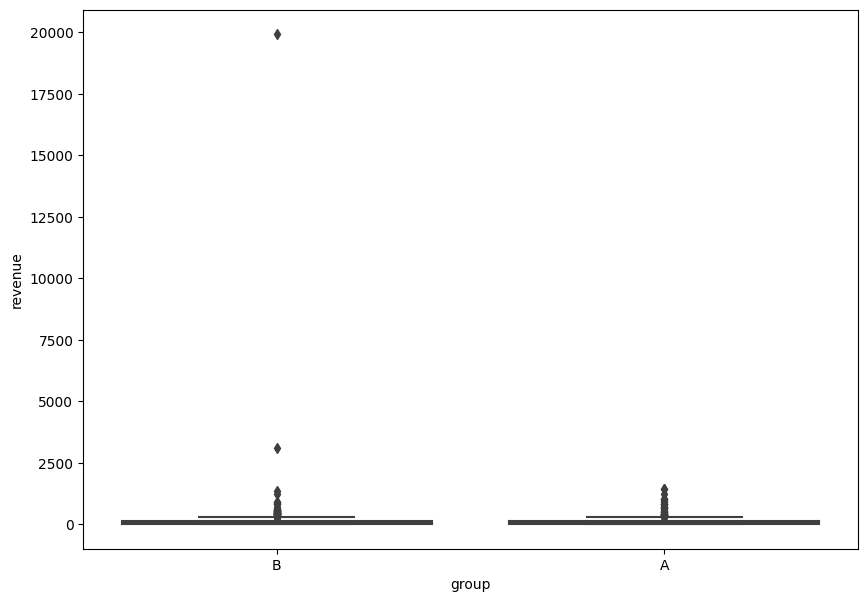

In [71]:
# Visualizar la distribucion de los grupo con un grafico de caja
plt.figure(figsize=(10,7))
sns.boxplot(data=orders_data, x='group', y='revenue')
plt.show()

In [72]:
# Realizar prueba Mann-Whitney
print(f"Prueba Mann-Whitney:\n")
print('Valor P: ', '{0:.3f}'.format(st.mannwhitneyu(revenue_group_a, revenue_group_b)[1]))
print('Diferencia Relativa: ', '{0:.3f}'.format(revenue_group_b.mean()/revenue_group_a.mean()-1))

Prueba Mann-Whitney:

Valor P:  0.692
Diferencia Relativa:  0.252


In [73]:
# Crear una lista para cada grupo con los datos del revenue para la prueba T Student
list_revenue_group_a = orders_data[orders_data['group'] == 'A']['revenue'].to_list()
list_revenue_group_b = orders_data[orders_data['group'] == 'B']['revenue'].to_list()

In [74]:
# Realizar prueba t de Student para comparar promedios
alpha=0.05

t_stat, p_value = st.ttest_ind(list_revenue_group_a, list_revenue_group_b, alternative='greater', equal_var=False)

print(f"Prueba t de Student:\n")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f} con un valor {alpha=}")

Prueba t de Student:

Estadístico t: -0.8886
Valor p: 0.8127 con un valor alpha=0.05


In [75]:
# Interpretar resultado de la prueba
print(f"\nNivel de significancia (α): {alpha}")
print(f"Diferencia en medias: Grupo B - Grupo A = ${revenue_group_b.mean() - revenue_group_a.mean():.2f}")
print(f"Diferencia relativa: {(revenue_group_b.mean()/revenue_group_a.mean() - 1)*100:.2f}%")

print(f"\nResultado de la prueba t:")
if p_value < alpha:
    print("✅ RESULTADO: La diferencia en tamaño promedio de pedido ES estadísticamente significativa")
    print("Rechazamos la hipótesis nula - hay diferencia real entre grupos")
else:
    print("❌ RESULTADO: La diferencia en tamaño promedio de pedido NO es estadísticamente significativa")
    print("No podemos rechazar la hipótesis nula - la diferencia podría ser por azar")


Nivel de significancia (α): 0.05
Diferencia en medias: Grupo B - Grupo A = $29.17
Diferencia relativa: 25.17%

Resultado de la prueba t:
❌ RESULTADO: La diferencia en tamaño promedio de pedido NO es estadísticamente significativa
No podemos rechazar la hipótesis nula - la diferencia podría ser por azar


### === Observaciones ===

Los resultados de la prueba son muy interesantes. Por un lado podemos observar que si hay diferencia en los promedios de cada grupo. Grupo A tiene 115.89 mientras que grupo B tiene 145.06 y su diferencia relativa es de 25.17%. Sin embargo al realizar la prueba T de Student independiente observamos que el resultado fue que la diferencia NO es estadisticamente significativa y la hipotesis nula no puede rechazarse, es decir, la prueba nos dice que en realidad no hay diferencia entre los grupos en cuanto al tamaño de compra promedio. Con el grafico de caja podemos observar que claramente los valores atipicos del grupo B estan afectando los resultados.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b>
<a class="tocSkip"></a><br>
<b>Éxito</b> - La comparación del tamaño promedio de pedido entre los grupos y la evaluación mediante pruebas estadísticas permiten analizar con claridad si la diferencia observada entre los grupos es realmente significativa.
</div>


## 2.11 Encontrar la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos filtrados

Vamos a volver a realizar las pruebas pero esta vez vamos a filtrar y eliminar los valores anomalos que pueden estar alterado los resultados de las pruebas.

In [76]:
# Extraer y agrupar datos: agrupamos por id de usuario y calculamos las ordenes unicas para cada grupo
orders_by_group_a = orders_data[orders_data['group']=='A'].groupby('visitor_id', as_index=False).agg({'transaction_id' : pd.Series.nunique})
orders_by_group_a.columns = ['visitor_id', 'orders']

orders_by_group_b = orders_data[orders_data['group']=='B'].groupby('visitor_id', as_index=False).agg({'transaction_id' : pd.Series.nunique})
orders_by_group_b.columns = ['visitor_id', 'orders']

In [77]:
# Extraer y almacenar usuarios con pedidos mayores a 2
users_with_many_orders = pd.concat(
    [
        orders_by_group_a[orders_by_group_a['orders'] > 2]['visitor_id'],
        orders_by_group_b[orders_by_group_b['orders'] > 2]['visitor_id'],
    ],
    axis=0,
)

# Extraer y almacenar usuarios con compras mayores a $436
users_with_expensive_orders = orders_data[orders_data['revenue'] > 436]['visitor_id']

# Unir usuarios y eliminar duplicados
abnormal_users = (
    pd.concat([users_with_many_orders, users_with_expensive_orders], axis=0)
    .drop_duplicates()
    .sort_values()
)

In [78]:
# Crear grupos y filtrar los usuarios anomalos
group_a_filtered = pd.concat(
    [
        orders_by_group_a[np.logical_not(orders_by_group_a['visitor_id']
            .isin(abnormal_users))]['orders'], 
        pd.Series(
            0, index=np.arange(visits_data[visits_data['group']=='A']['visits'].sum() - len(orders_by_group_a['orders'])),name='orders')],
    axis=0
)

group_b_filtered = pd.concat(
    [
        orders_by_group_a[np.logical_not(orders_by_group_a['visitor_id']
            .isin(abnormal_users))]['orders'],
        pd.Series(
            0, index=np.arange(visits_data[visits_data['group']=='B']['visits'].sum() - len(orders_by_group_a['orders'])),name='orders')],
    axis=0
)



In [79]:
# Aplicar prueba de Mann-Whitney con los grupos filtrados
print("Prueba Mann-Whitney:\n")
print("Valor P: ", "{0:.5f}".format(st.mannwhitneyu(group_a_filtered, group_b_filtered)[1]))
print("Diferencia relativa: ", "{0:.3f}".format(group_b_filtered.mean()/group_a_filtered.mean()-1))

Prueba Mann-Whitney:

Valor P:  0.88326
Diferencia relativa:  -0.010


In [80]:
# Volver a comparar valor p con alpha y evaluar las hipotesis
alpha = 0.05
results = st.mannwhitneyu(group_a_filtered, group_b_filtered)

print('\np-value: ', results.pvalue)

if (results.pvalue < alpha):
    print("\nHipótesis nula rechazada: existen diferencias significativas entre las distribuciones de los dos grupos comparados.")
else:
    print("\nNo se pudo rechazar la hipótesis nula: no podemos sacar conclusiones sobre la diferencia.")


p-value:  0.88326426319878

No se pudo rechazar la hipótesis nula: no podemos sacar conclusiones sobre la diferencia.


### === Observaciones ===

Los resultados cambiaron. Anteriormente los resultados eran que SI habia una diferencia estadisticamente significativa entre las conversiones de los grupos A y B. Ahora, la prueba concluyo que no podemos asumir que hay una diferencia significativa. Claramente los valores extremos estaban alterando los resultados de las pruebas.

### 2.12 Encontrar la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos filtrados

Ahora vamos a filtrar los datos extremos y volver a realizar las pruebas para la diferencia en el tamaño promedio de compra entre los grupoa A y B.

In [81]:
orders_by_group_a = orders_data[orders_data['group']=='A'].groupby('visitor_id', as_index=False).agg({'transaction_id' : pd.Series.nunique})
orders_by_group_a.columns = ['visitor_id', 'orders']

orders_by_group_b = orders_data[orders_data['group']=='B'].groupby('visitor_id', as_index=False).agg({'transaction_id' : pd.Series.nunique})
orders_by_group_b.columns = ['visitor_id', 'orders']

In [82]:
# Extraer y almacenar usuarios con pedidos mayores a 2
users_with_many_orders = pd.concat(
    [
        orders_by_group_a[orders_by_group_a['orders'] > 2]['visitor_id'],
        orders_by_group_b[orders_by_group_b['orders'] > 2]['visitor_id'],
    ],
    axis=0,
)

# Extraer y almacenar usuarios con compras mayores a $436
users_with_expensive_orders = orders_data[orders_data['revenue'] > 436]['visitor_id']

# Unir usuarios y eliminar duplicados
abnormal_users = (
    pd.concat([users_with_many_orders, users_with_expensive_orders], axis=0)
    .drop_duplicates()
    .sort_values()
)

In [83]:
orders_group_a_filtered =  orders_data[np.logical_and(
        orders_data['group']=='A',
        np.logical_not(orders_data['visitor_id'].isin(abnormal_users)))]['revenue']

orders_group_b_filtered = orders_data[np.logical_and(
        orders_data['group']=='B',
        np.logical_not(orders_data['visitor_id'].isin(abnormal_users)))]['revenue']

In [84]:
print("Prueba Mann-Whitney:\n")
print("Valor P: ", "{0:.3f}".format(st.mannwhitneyu(orders_group_a_filtered, orders_group_b_filtered)[1]))
print("Diferencia Relativa: ", "{0:.3f}".format(orders_group_b_filtered.mean()/orders_group_a_filtered.mean() - 1))

Prueba Mann-Whitney:

Valor P:  0.744
Diferencia Relativa:  -0.028


In [92]:
# Interpretar resultado de la prueba
alpha = 0.05
results = st.mannwhitneyu(orders_group_a_filtered, orders_group_b_filtered)

print('\np-value: ', results.pvalue)

print(f"\nNivel de significancia (α): {alpha}")
print(f"Diferencia en medias: Grupo B - Grupo A = ${revenue_group_b.mean() - revenue_group_a.mean():.2f}")
print(f"Diferencia relativa: {(orders_group_b_filtered.mean()/orders_group_a_filtered.mean() - 1)*100:.2f}%")

print(f"\nResultado de la prueba Mann-Whitney:")
if p_value < alpha:
    print("✅ RESULTADO: La diferencia en tamaño promedio de pedido ES estadísticamente significativa")
    print("Rechazamos la hipótesis nula - hay diferencia real entre grupos")
else:
    print("❌ RESULTADO: La diferencia en tamaño promedio de pedido NO es estadísticamente significativa")
    print("No podemos rechazar la hipótesis nula - la diferencia podría ser por azar")


p-value:  0.743836016813833

Nivel de significancia (α): 0.05
Diferencia en medias: Grupo B - Grupo A = $29.17
Diferencia relativa: -2.80%

Resultado de la prueba Mann-Whitney:
❌ RESULTADO: La diferencia en tamaño promedio de pedido NO es estadísticamente significativa
No podemos rechazar la hipótesis nula - la diferencia podría ser por azar


In [87]:
# Crear una lista para cada grupo con los datos del revenue para la prueba T Student
to_list_revenue_group_a = orders_group_a_filtered.to_list()
to_list_revenue_group_b = orders_group_b_filtered.to_list()

In [89]:
# Realizar prueba t de Student para comparar promedios
alpha=0.05

t_stat, p_value = st.ttest_ind(to_list_revenue_group_a, to_list_revenue_group_b, alternative='greater', equal_var=False)

print(f"Prueba t de Student:\n")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f} con un valor {alpha=}")

Prueba t de Student:

Estadístico t: 0.4172
Valor p: 0.3383 con un valor alpha=0.05


In [91]:
# Interpretar resultado de la prueba
print(f"\nNivel de significancia (α): {alpha}")
print(f"Diferencia en medias: Grupo B - Grupo A = ${orders_group_b_filtered.mean() - orders_group_a_filtered.mean():.2f}")
print(f"Diferencia relativa: {(orders_group_b_filtered.mean()/orders_group_a_filtered.mean() - 1)*100:.2f}%")

print(f"\nResultado de la prueba t:")
if p_value < alpha:
    print("✅ RESULTADO: La diferencia en tamaño promedio de pedido ES estadísticamente significativa")
    print("Rechazamos la hipótesis nula - hay diferencia real entre grupos")
else:
    print("❌ RESULTADO: La diferencia en tamaño promedio de pedido NO es estadísticamente significativa")
    print("No podemos rechazar la hipótesis nula - la diferencia podría ser por azar")


Nivel de significancia (α): 0.05
Diferencia en medias: Grupo B - Grupo A = $-2.34
Diferencia relativa: -2.80%

Resultado de la prueba t:
❌ RESULTADO: La diferencia en tamaño promedio de pedido NO es estadísticamente significativa
No podemos rechazar la hipótesis nula - la diferencia podría ser por azar


### === Observaciones ===

Realizamos la prueba T Student y la prueba Mann-Whitney. En ambos casos el resultado fue que no hay diferencias significativas en el tamaño promedio de compra de los grupos A y B. En la prueba anterior, donde no habiamos filtrado los valores extremos, el resultado era similar. Entonces, segun los resultados de las pruebas, no hay una diferencia significativa entre los grupos A y B.

## 2.13 Tomar una decisión basada en los resultados de la prueba

### Conclusion

La recomendacion para este caso segun los analisis realizados, los resultados de las pruebas y la evidencia recogida es que deberiamos detener la prueba y concluir que no hay diferencia entre los grupos. La diferencias observadas en los grupos se debio principalmente a los valores extremos encontrados en el grupo B, que provocaron que los resultados de varios analisis fueran favorables para este grupo. Al eliminar estos valores atipicos pudimos observar que no hay una diferencia notable entre los grupos.

* Recomendacion: Detener la prueba y concluir que no hay diferencias significativas entre los grupos A y B.

# Comentario General del Revisor

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b>
<a class="tocSkip"></a>

El proyecto presenta un proceso analítico bien estructurado que aborda correctamente tanto la **priorización de hipótesis** como el **análisis del test A/B**, siguiendo los pasos metodológicos esperados para este tipo de estudio. A lo largo del notebook se observa un flujo lógico de trabajo que permite comprender cómo se preparan los datos, cómo se exploran y cómo se interpretan los resultados obtenidos.

#### Puntos Positivos:

* **Priorización de hipótesis:** Se aplicaron correctamente los frameworks **ICE y RICE**, lo que permitió comparar cómo cambia la priorización al incorporar el alcance dentro del análisis.

* **Procesamiento y revisión de datos:** Se realizó una inspección inicial clara de los datasets, incluyendo verificación de estructura, tipos de datos, duplicados y estandarización de columnas, lo que facilita trabajar con los datos de manera consistente.

* **Análisis exploratorio y visualización:** Se construyeron gráficos adecuados para analizar ingresos acumulados, tamaño promedio de pedido, tasas de conversión y dispersión de pedidos y precios, permitiendo interpretar el comportamiento de ambos grupos durante el experimento.

* **Detección y tratamiento de valores atípicos:** El análisis incluyó la identificación de anomalías mediante percentiles y su posterior filtrado, lo que permitió evaluar cómo estos valores afectan los resultados del experimento.

* **Evaluación estadística del experimento:** Se aplicaron pruebas estadísticas apropiadas para comparar conversión y tamaño promedio de pedido entre los grupos, tanto con datos en bruto como con datos filtrados, lo que fortalece la validez del análisis.

* **Interpretación y toma de decisiones:** La conclusión final se basa en la evidencia obtenida durante el análisis y presenta una decisión razonada sobre el resultado del test A/B.

En conjunto, el notebook muestra un proceso completo de análisis de experimentos A/B, integrando exploración de datos, visualización, análisis estadístico y toma de decisiones basada en datos.
